# CKD Model Demo Notebook
## Load Trained Model, Run Inference, and Interpret Performance

This notebook is a dedicated demo workflow. It does **not** retrain the model.

What this notebook does:
- Loads a fully trained model bundle from disk
- Runs inference on held-out samples
- Evaluates model performance
- Produces interpretation-focused visualizations

## One-Time Export From Training Notebook

Run the snippet below **once** in `Project1_code.ipynb` after training completes.

```python
from pathlib import Path
import joblib

Path("models").mkdir(exist_ok=True)

demo_bundle = {
    "model": mlp_model,
    "X_test": X_test_scaled,
    "y_test": y_test,
    "feature_names": X_test_scaled.columns.tolist() if hasattr(X_test_scaled, "columns") else None,
    "metadata": {
        "dataset": "OpenML 42972 (CKD)",
        "model_name": "MLP Neural Network"
    }
}

joblib.dump(demo_bundle, "models/ckd_mlp_demo_bundle.joblib")
print("Saved: models/ckd_mlp_demo_bundle.joblib")
```

After that, return to this notebook and run all cells.

In [1]:
# Imports
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("deep")

print("Imports loaded.")

Imports loaded.


In [2]:
# Optional bootstrap: create demo bundle from local dataset if missing
from io import StringIO
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier


def load_local_arff_as_dataframe(data_path):
    """Load ARFF with a lightweight parser that tolerates STRING attributes."""
    lines = data_path.read_text(encoding="utf-8", errors="ignore").splitlines()

    attributes = []
    data_lines = []
    in_data = False

    for line in lines:
        s = line.strip()
        if not s or s.startswith("%"):
            continue
        s_lower = s.lower()
        if not in_data:
            if s_lower.startswith("@attribute"):
                parts = s.split(maxsplit=2)
                if len(parts) >= 2:
                    attributes.append(parts[1].strip("'\""))
            elif s_lower.startswith("@data"):
                in_data = True
        else:
            data_lines.append(s)

    if not attributes or not data_lines:
        raise ValueError("Could not parse ARFF header/data sections.")

    # Repair rows if any line wraps by accumulating until comma count matches columns.
    repaired_rows = []
    buffer = ""
    needed_commas = len(attributes) - 1
    for raw in data_lines:
        buffer = f"{buffer}{raw}" if buffer else raw
        if buffer.count(",") >= needed_commas:
            repaired_rows.append(buffer)
            buffer = ""
    if buffer:
        repaired_rows.append(buffer)

    csv_like = "\n".join(repaired_rows)
    df = pd.read_csv(
        StringIO(csv_like),
        header=None,
        names=attributes,
        na_values=["?", " ?", "", "nan", "NaN"],
        keep_default_na=True,
    )
    return df


def build_demo_bundle_from_local_arff(
    data_path=Path("data/kidney.arff"),
    output_path=Path("models/ckd_mlp_demo_bundle.joblib"),
    random_state=42,
):
    """Train a reproducible demo pipeline from local ARFF and save a loadable bundle."""
    if not data_path.exists():
        raise FileNotFoundError(f"Local dataset not found: {data_path}")

    output_path.parent.mkdir(parents=True, exist_ok=True)
    df = load_local_arff_as_dataframe(data_path)

    candidate_targets = ["classification", "class", "target", "label", "y"]
    target_col = next((c for c in candidate_targets if c in df.columns), df.columns[-1])

    X = df.drop(columns=[target_col]).copy()
    y = (
        df[target_col]
        .astype(str)
        .str.strip()
        .str.strip("'\"")
        .str.replace(r"\\s+", "", regex=True)
        .str.lower()
        .replace({"ckdt": "ckd"})
    )

    # Convert columns with mostly numeric values to numeric dtype.
    for col in X.columns:
        coerced = pd.to_numeric(X[col], errors="coerce")
        if coerced.notna().mean() >= 0.8:
            X[col] = coerced

    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                num_cols,
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]),
                cat_cols,
            ),
        ],
        remainder="drop",
    )

    y_encoder = LabelEncoder()
    y_encoded = y_encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=random_state, stratify=y_encoded
    )

    model = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            (
                "classifier",
                MLPClassifier(
                    hidden_layer_sizes=(100, 50),
                    max_iter=500,
                    random_state=random_state,
                    early_stopping=True,
                ),
            ),
        ]
    )

    model.fit(X_train, y_train)

    bundle = {
        "model": model,
        "X_test": X_test,
        "y_test": y_test,
        "feature_names": X_train.columns.tolist(),
        "metadata": {
            "dataset": "kidney.arff (local fallback)",
            "model_name": "MLP Pipeline (OneHot + StandardScaler)",
            "target_column": target_col,
            "label_classes": y_encoder.classes_.tolist(),
        },
    }

    joblib.dump(bundle, output_path)
    return output_path


print("Bootstrap helper ready. If bundle is missing, next cell can auto-create it.")

Bootstrap helper ready. If bundle is missing, next cell can auto-create it.


In [3]:
# Load saved model bundle
BUNDLE_PATH = Path("models/ckd_mlp_demo_bundle.joblib")

if not BUNDLE_PATH.exists():
    print(f"Bundle not found at {BUNDLE_PATH}. Building fallback bundle from local data...")
    created_path = build_demo_bundle_from_local_arff(output_path=BUNDLE_PATH)
    print(f"Created: {created_path}")

bundle = joblib.load(BUNDLE_PATH)

required_keys = ["model", "X_test", "y_test"]
missing = [k for k in required_keys if k not in bundle]
if missing:
    raise KeyError(f"Bundle is missing required keys: {missing}")

model = bundle["model"]
X_test = bundle["X_test"]
y_test = bundle["y_test"]
feature_names = bundle.get("feature_names")
metadata = bundle.get("metadata", {})

print("Bundle loaded successfully.")
print(f"Model: {metadata.get('model_name', type(model).__name__)}")
print(f"Dataset: {metadata.get('dataset', 'N/A')}")
print(f"X_test shape: {getattr(X_test, 'shape', None)}")
print(f"y_test length: {len(y_test)}")

Bundle loaded successfully.
Model: MLP Pipeline (OneHot + StandardScaler)
Dataset: kidney.arff (local fallback)
X_test shape: (80, 25)
y_test length: 80


In [4]:
# Helper functions for evaluation and plotting
def infer_positive_label(y_true, estimator=None):
    """Pick a stable positive class label for binary tasks."""
    if estimator is not None and hasattr(estimator, "classes_") and len(estimator.classes_) >= 2:
        # For sklearn classifiers, classes_ order aligns with predict_proba columns.
        return estimator.classes_[-1]
    unique_vals = sorted(pd.Series(y_true).dropna().unique().tolist())
    if len(unique_vals) < 2:
        raise ValueError("Need at least two classes to evaluate binary metrics.")
    return unique_vals[-1]


def get_probabilities(estimator, X):
    if hasattr(estimator, "predict_proba"):
        proba = estimator.predict_proba(X)
        if proba.ndim == 2 and proba.shape[1] >= 2:
            return proba[:, -1]
    if hasattr(estimator, "decision_function"):
        raw = estimator.decision_function(X)
        raw = np.asarray(raw, dtype=float)
        return (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)
    return None


def evaluate_predictions(y_true, y_pred, y_proba=None, pos_label=None):
    results = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    if y_proba is not None:
        y_bin = (pd.Series(y_true) == pos_label).astype(int).to_numpy()
        results["ROC-AUC"] = roc_auc_score(y_bin, y_proba)
    return results


def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


def plot_roc_pr(y_true, y_proba, pos_label):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    y_bin = (pd.Series(y_true) == pos_label).astype(int).to_numpy()
    fpr, tpr, _ = roc_curve(y_bin, y_proba)
    auc = roc_auc_score(y_bin, y_proba)
    axes[0].plot(fpr, tpr, label=f"ROC AUC = {auc:.3f}", linewidth=2)
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.7)
    axes[0].set_title("ROC Curve")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].legend(loc="lower right")

    precision, recall, _ = precision_recall_curve(y_bin, y_proba)
    axes[1].plot(recall, precision, linewidth=2, color="#e67e22")
    axes[1].set_title("Precision-Recall Curve")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")

    plt.tight_layout()
    plt.show()

Performance Metrics (Test Set):


,Value
Accuracy,0.9875
Precision,0.9879
Recall,0.9875
F1-Score,0.9875
ROC-AUC,1.0000



Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        50
           2       0.97      1.00      0.98        30

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



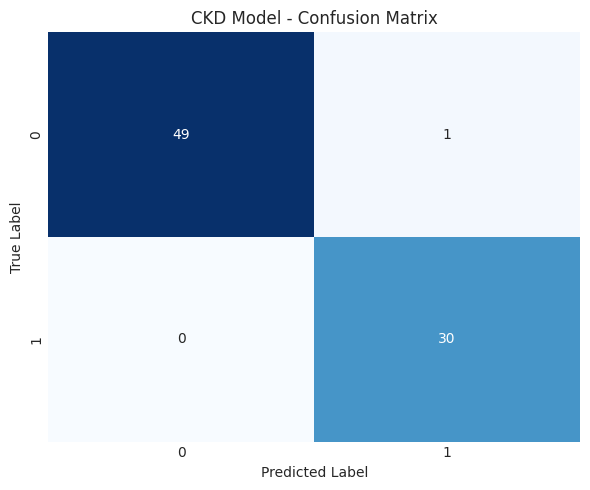

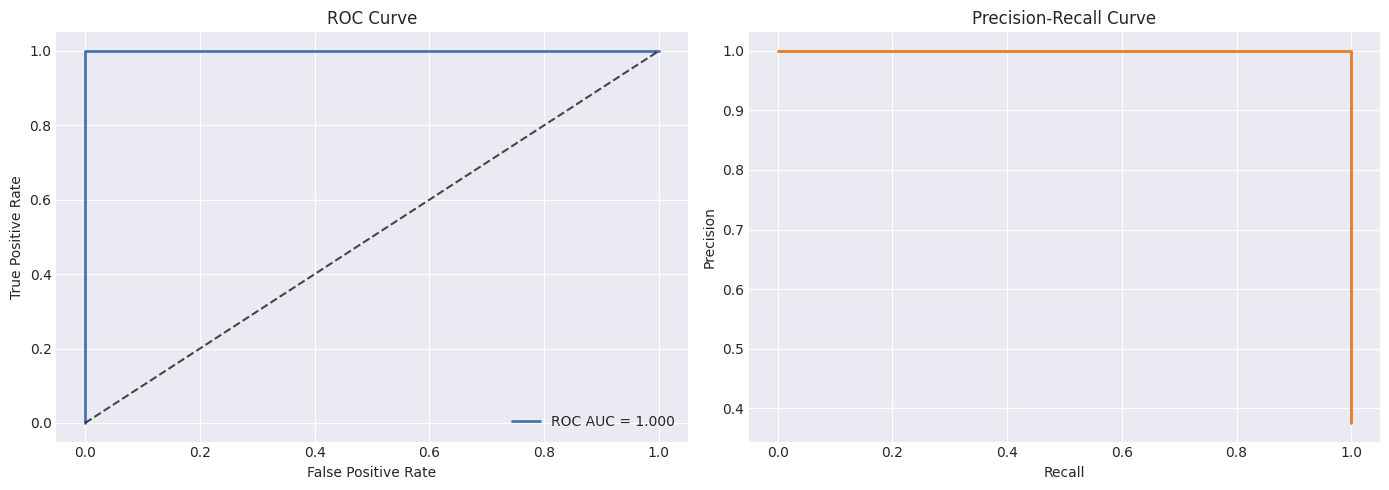

In [5]:
# Run inference on held-out test set and evaluate performance
y_pred = model.predict(X_test)
y_proba = get_probabilities(model, X_test)
pos_label = infer_positive_label(y_test, estimator=model)

metrics = evaluate_predictions(y_test, y_pred, y_proba, pos_label=pos_label)
metrics_df = pd.DataFrame([metrics]).T
metrics_df.columns = ["Value"]

print("Performance Metrics (Test Set):")
display(metrics_df.style.format("{:.4f}"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plot_confusion(y_test, y_pred, title="CKD Model - Confusion Matrix")
if y_proba is not None:
    plot_roc_pr(y_test, y_proba, pos_label=pos_label)
else:
    print("ROC/PR plots skipped: model does not provide probabilities.")

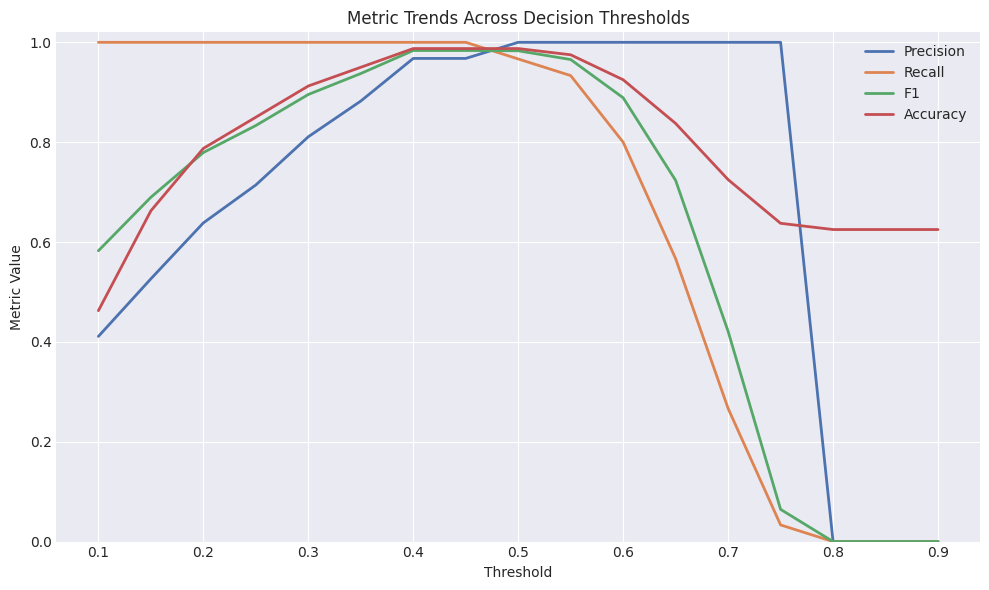

Best F1 threshold: 0.40
              value
threshold  0.400000
precision  0.967742
recall     1.000000
f1         0.983607
accuracy   0.987500


In [6]:
# Threshold analysis to support interpretation and deployment choices
if y_proba is None:
    print("Threshold analysis unavailable because probabilities are not available.")
else:
    y_bin = (pd.Series(y_test) == pos_label).astype(int).to_numpy()
    thresholds = np.linspace(0.1, 0.9, 17)
    rows = []

    for t in thresholds:
        pred_t = (y_proba >= t).astype(int)
        rows.append({
            "threshold": t,
            "precision": precision_score(y_bin, pred_t, zero_division=0),
            "recall": recall_score(y_bin, pred_t, zero_division=0),
            "f1": f1_score(y_bin, pred_t, zero_division=0),
            "accuracy": accuracy_score(y_bin, pred_t),
        })

    th_df = pd.DataFrame(rows)

    plt.figure(figsize=(10, 6))
    plt.plot(th_df["threshold"], th_df["precision"], label="Precision", linewidth=2)
    plt.plot(th_df["threshold"], th_df["recall"], label="Recall", linewidth=2)
    plt.plot(th_df["threshold"], th_df["f1"], label="F1", linewidth=2)
    plt.plot(th_df["threshold"], th_df["accuracy"], label="Accuracy", linewidth=2)
    plt.title("Metric Trends Across Decision Thresholds")
    plt.xlabel("Threshold")
    plt.ylabel("Metric Value")
    plt.ylim(0, 1.02)
    plt.legend()
    plt.tight_layout()
    plt.show()

    best_f1 = th_df.loc[th_df["f1"].idxmax()]
    print(f"Best F1 threshold: {best_f1['threshold']:.2f}")
    print(best_f1.to_frame(name="value"))

In [7]:
# Inference demo: single sample and batch samples
if isinstance(X_test, pd.DataFrame):
    sample_one = X_test.iloc[[0]].copy()
    sample_batch = X_test.iloc[:5].copy()
else:
    sample_one = X_test[:1]
    sample_batch = X_test[:5]

single_pred = model.predict(sample_one)[0]
single_proba = get_probabilities(model, sample_one)

print("Single-sample inference:")
print(f"Predicted class: {single_pred}")
if single_proba is not None:
    print(f"Predicted positive probability: {single_proba[0]:.4f}")

batch_pred = model.predict(sample_batch)
batch_proba = get_probabilities(model, sample_batch)

if isinstance(sample_batch, pd.DataFrame):
    out = pd.DataFrame(index=sample_batch.index)
else:
    out = pd.DataFrame(index=range(len(batch_pred)))

out["predicted_class"] = batch_pred
if batch_proba is not None:
    out["predicted_positive_probability"] = batch_proba

print("\nBatch inference (first 5 rows):")
display(out)

Single-sample inference:
Predicted class: 0
Predicted positive probability: 0.1867

Batch inference (first 5 rows):


,predicted_class,predicted_positive_probability
161,0,0.186730
20,0,0.160481
392,2,0.711866
303,2,0.700264
339,2,0.526932


## Notes

- This demo notebook assumes the saved artifact already contains preprocessed test features (`X_test`) compatible with the model.
- If you want raw-patient-input inference, save and load a full preprocessing pipeline object together with the model.
- For deployment, use versioned artifact paths and include model metadata (training date, feature schema, and validation scores).